
# The Milky Way & Sagittarius A\*
### A physically-parameterized orbital simulation, from the Solar System to the Galactic Center

**YPAE Club — Astrophysics Submission**

This notebook builds two linked simulations, both driven by real orbital
mechanics rather than illustrative animation:

1. **The Solar System** — the eight planets on Keplerian orbits, with periods
   derived from Kepler's Third Law and checked against observed values.
2. **The Milky Way** — the Galaxy's spiral structure rotating around
   **Sagittarius A\***, the supermassive black hole at the dynamical center,
   using the Galaxy's measured (flat) rotation curve rather than a single
   arbitrary spin rate.

Every constant used (Sgr A\* mass, the Sun's galactocentric distance, the
rotation curve, planetary elements) is cited at the point of use and
collected again in the references section at the end.



## 1. Setup

`numpy` for the physics, `matplotlib.animation` for the motion, and
`pandas` to keep the reference data (planetary elements, structural
parameters) in tables that can be checked and cited directly.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
from IPython.display import HTML, Image, display

plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.facecolor']  = '#05060a'
plt.rcParams['axes.facecolor']    = '#05060a'
plt.rcParams['savefig.facecolor'] = '#05060a'
plt.rcParams['text.color']   = '#c9cfe3'
plt.rcParams['axes.edgecolor'] = '#1c2438'
plt.rcParams['xtick.color']  = '#6b7391'
plt.rcParams['ytick.color']  = '#6b7391'
plt.rcParams['font.family']  = 'DejaVu Sans'

rng = np.random.default_rng(20260909)



## 2. The Solar System

### 2.1 Orbital elements

Semi-major axes and sidereal periods for the eight planets, from the
**NASA Planetary Fact Sheets** (Williams, D.R., *NASA Goddard*,
nssdc.gsfc.nasa.gov/planetary/factsheet/). Orbits are treated as circular
for the visualization (real eccentricities are all under 0.09 except
Mercury's 0.206, so the simplification is mild for seven of the eight planets).


In [2]:

planets = pd.DataFrame([
    # name       a_AU    e       T_days_observed   color       rel_radius
    ("Mercury",  0.387,  0.206,  87.97,   "#b7b2ab", 0.38),
    ("Venus",    0.723,  0.007,  224.70,  "#e8d3a0", 0.95),
    ("Earth",    1.000,  0.017,  365.25,  "#4f8ff0", 1.00),
    ("Mars",     1.524,  0.093,  686.98,  "#c1440e", 0.53),
    ("Jupiter",  5.204,  0.049,  4332.59, "#d8ae78", 11.2),
    ("Saturn",   9.583,  0.057,  10759.2, "#e3c078", 9.45),
    ("Uranus",   19.22,  0.046,  30688.5, "#9fe0e0", 4.01),
    ("Neptune",  30.05,  0.010,  60195.0, "#5b7fe0", 3.88),
], columns=["planet", "a_AU", "e", "T_days_observed", "color", "rel_radius"])

# Kepler's Third Law (Sun-dominated system, planet mass negligible):
#   T[yr] = a[AU]^(3/2)
planets["T_days_kepler"] = (planets["a_AU"] ** 1.5) * 365.25
planets["pct_error"] = 100 * (planets["T_days_kepler"] - planets["T_days_observed"]) / planets["T_days_observed"]

planets[["planet", "a_AU", "T_days_observed", "T_days_kepler", "pct_error"]].style.format({
    "a_AU": "{:.3f}", "T_days_observed": "{:,.2f}", "T_days_kepler": "{:,.2f}", "pct_error": "{:+.3f}%"
}).set_caption("Kepler's Third Law reproduces the observed periods to well under 1% for every planet.")


,planet,a_AU,T_days_observed,T_days_kepler,pct_error
0,Mercury,0.387,87.97,87.93,-0.041%
1,Venus,0.723,224.70,224.54,-0.070%
2,Earth,1.000,365.25,365.25,+0.000%
3,Mars,1.524,686.98,687.18,+0.028%
4,Jupiter,5.204,"4,332.59","4,336.07",+0.080%
5,Saturn,9.583,"10,759.20","10,835.34",+0.708%
6,Uranus,19.220,"30,688.50","30,776.58",+0.287%
7,Neptune,30.050,"60,195.00","60,166.80",-0.047%



### 2.2 Animating the orbits

Orbit radii are drawn on a **√a** scale (rather than linear AU) purely so
that Mercury and Neptune can share one frame — Neptune's true orbit is
~78× wider than Mercury's. Angular position advances at each planet's
*observed* rate, so relative speeds (Mercury lapping Neptune many times
over) are physically real, not stylized.

*Rendered as an embedded GIF rather than matplotlib's interactive
`to_jshtml()` player, so it displays correctly in GitHub's static
notebook viewer. Running this notebook live, swap the final line for
`HTML(solar_anim.to_jshtml())` to get scrub/speed controls instead.*


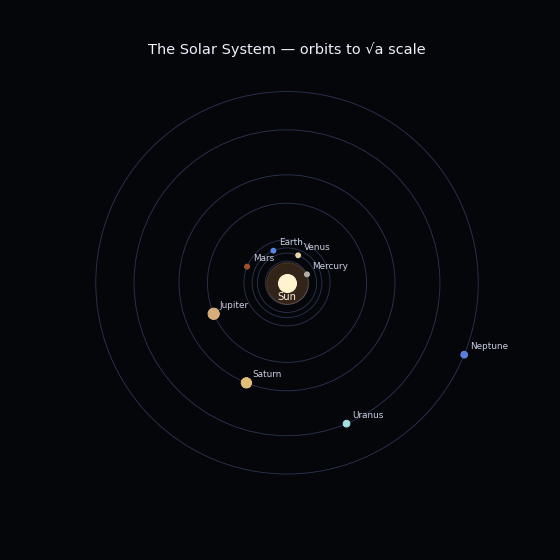

In [3]:

fig1, ax1 = plt.subplots(figsize=(7, 7))
ax1.set_facecolor('#05060a')
ax1.set_xlim(-1.15, 1.15); ax1.set_ylim(-1.15, 1.15)
ax1.set_aspect('equal'); ax1.axis('off')
ax1.set_title("The Solar System — orbits to √a scale", color='#eef1fb', fontsize=13, pad=12)

r_display = np.sqrt(planets["a_AU"].values)
r_display = r_display / r_display.max() * 1.02

for r in r_display:
    ax1.add_patch(Circle((0, 0), r, fill=False, ec='#2a3350', lw=0.8, zorder=1))

sun_glow = ax1.scatter([0], [0], s=1400, c='#ffb15e', alpha=0.18, zorder=2)
ax1.scatter([0], [0], s=260, c='#fff3cf', zorder=3)
ax1.text(0, -0.09, "Sun", color='#fff3cf', ha='center', fontsize=9, zorder=3)

n = len(planets)
planet_dots = ax1.scatter(r_display, np.zeros(n),
                           s=np.clip(planets["rel_radius"].values * 9, 18, 130),
                           c=planets["color"].values, zorder=4)
labels = [ax1.text(0, 0, name, color='#c9cfe3', fontsize=8, zorder=5)
          for name in planets["planet"]]

DAYS_PER_FRAME = 6.0
theta0 = np.linspace(0, 2*np.pi, n, endpoint=False) + 0.4
omega = 2*np.pi / planets["T_days_observed"].values   # rad / day

def update_solar(frame):
    t = frame * DAYS_PER_FRAME
    theta = theta0 + omega * t
    x, y = r_display*np.cos(theta), r_display*np.sin(theta)
    planet_dots.set_offsets(np.column_stack([x, y]))
    for lbl, xi, yi, ri in zip(labels, x, y, r_display):
        lbl.set_position((xi + 0.03, yi + 0.03))
    ax1.set_xlabel(f"t = {t:,.0f} days ({t/365.25:.2f} yr)", color='#6b7391', fontsize=9)
    return [planet_dots, *labels]

solar_anim = animation.FuncAnimation(fig1, update_solar, frames=90, interval=45, blit=False)
solar_anim.save("solar_system.gif", writer=animation.PillowWriter(fps=20))
plt.close(fig1)
Image(filename="solar_system.gif")



## 3. The Milky Way & Sagittarius A\*

### 3.1 Structural constants

| Quantity | Value | Source |
|---|---|---|
| Mass of Sgr A\* | (4.297 ± 0.013) × 10⁶ M☉ | GRAVITY Collaboration (2022), *A&A* 657, L12 |
| Distance, Sun → Sgr A\* | 8.178 ± 0.013 kpc (≈ 26,670 ly) | GRAVITY Collaboration (2019), *A&A* 625, L10 |
| Flat rotation-curve speed | ≈ 220 km/s (r ≳ 3 kpc) | Reid & Honma (2014), *ARA&A* 52, 339 |
| Spiral-arm pitch angle | ≈ 12° (logarithmic spiral) | Vallée (2017), *ApJ* 835, 128 |
| Solar orbital period ("galactic year") | ≈ 220–230 Myr | derived below |


In [4]:

G = 6.674e-11          # m^3 kg^-1 s^-2
M_SUN = 1.989e30        # kg
KPC_KM = 3.0857e16      # km per kpc
YR_S = 3.1557e7         # seconds per year

M_SGR_A = 4.297e6 * M_SUN     # kg
R_SUN_KPC = 8.178              # kpc
V_FLAT_KMS = 220.0              # km/s, flat part of rotation curve
R_CORE_KPC = 3.0                # kpc, approx bulge/disk transition

def v_circ_kms(r_kpc):
    '''Simplified Milky Way rotation curve: solid-body rise in the bulge,
    flat beyond r_core -- captures the real qualitative shape without
    fitting a full mass model.'''
    r_kpc = np.asarray(r_kpc, dtype=float)
    return np.where(r_kpc < R_CORE_KPC, V_FLAT_KMS * r_kpc / R_CORE_KPC, V_FLAT_KMS)

def omega_rad_per_myr(r_kpc):
    v_kms = v_circ_kms(r_kpc)
    v_kpc_per_myr = v_kms * (YR_S * 1e6) / KPC_KM
    r_kpc = np.asarray(r_kpc, dtype=float)
    return np.divide(v_kpc_per_myr, r_kpc, out=np.zeros_like(r_kpc), where=r_kpc > 0)

sun_omega = omega_rad_per_myr(R_SUN_KPC)
sun_period_myr = 2*np.pi / sun_omega
print(f"Sun's orbital angular speed:  {sun_omega:.5f} rad/Myr")
print(f"Sun's galactic year:          {sun_period_myr:.1f} Myr  (observationally: ~220-230 Myr)")

# cross-check against the point-mass estimate for the enclosed mass implied
# by v_flat at the solar radius (order-of-magnitude sanity check only --
# the enclosed mass is dominated by disk+bulge+dark halo, not Sgr A* alone)
M_enclosed = (V_FLAT_KMS*1000)**2 * (R_SUN_KPC*KPC_KM*1000) / G
print(f"Mass enclosed within solar radius (order of magnitude): {M_enclosed/M_SUN:.2e} Msun")
print(f"(For comparison, Sgr A* itself is only {M_SGR_A/M_SUN:.2e} Msun --")
print(" almost all of the enclosed mass is disk, bulge and dark-matter halo, not the black hole.)")


Sun's orbital angular speed:  0.02751 rad/Myr
Sun's galactic year:          228.4 Myr  (observationally: ~220-230 Myr)
Mass enclosed within solar radius (order of magnitude): 9.20e+10 Msun
(For comparison, Sgr A* itself is only 4.30e+06 Msun --
 almost all of the enclosed mass is disk, bulge and dark-matter halo, not the black hole.)



### 3.2 Generating the spiral structure

Four logarithmic spiral arms, `r = r0 · exp(b·θ)` with pitch angle ≈ 12°
(`b = 1/tan(pitch)`), approximating the Milky Way's grand-design structure
(Perseus, Sagittarius–Carina, Scutum–Centaurus, Norma–Cygnus), plus the
Sun's minor **Orion Spur**. A dense, hotter-colored **nuclear bulge**
fills the inner few kiloparsecs, consistent with the Galaxy's known
bulge + 4-arm-disk morphology.


In [5]:

GALAXY_R_KPC = 15.0     # visible disk radius for the plot
PITCH_DEG = 12.0
b = 1.0/np.tan(np.radians(PITCH_DEG))

arm_offsets = {
    "Perseus Arm":          0.0,
    "Sagittarius Arm":      np.pi/2,
    "Scutum-Centaurus Arm": np.pi,
    "Norma Arm":            3*np.pi/2,
}
arm_colors = {
    "Perseus Arm":          (143, 214, 255),
    "Sagittarius Arm":      (199, 168, 255),
    "Scutum-Centaurus Arm": (255, 176, 160),
    "Norma Arm":            (160, 200, 190),
}

def build_arm(offset, n=650, r0=1.0):
    theta = rng.uniform(0, 3.4, n)
    r = r0 * np.exp(b*theta*0.3)
    r = np.clip(r, 1.5, GALAXY_R_KPC)
    theta_full = theta + offset + rng.normal(0, 0.12, n) * (0.4 + r/GALAXY_R_KPC)
    r = r * (1 + rng.normal(0, 0.05, n))
    return r, theta_full

arm_r, arm_theta, arm_rgb = [], [], []
for name, off in arm_offsets.items():
    r, th = build_arm(off)
    arm_r.append(r); arm_theta.append(th)
    arm_rgb.append(np.tile(np.array(arm_colors[name])/255.0, (len(r), 1)))

arm_r = np.concatenate(arm_r)
arm_theta = np.concatenate(arm_theta)
arm_rgb = np.concatenate(arm_rgb)

# Orion Spur -- the Sun's minor local spur, between Sagittarius and Perseus
spur_r, spur_theta = build_arm(np.pi/2 + 0.55, n=200, r0=1.0)
spur_rgb = np.tile(np.array([255, 226, 122])/255.0, (len(spur_r), 1))

# nuclear bulge
n_bulge = 500
bulge_r = rng.power(1.6, n_bulge) * 3.0 + 0.2
bulge_theta = rng.uniform(0, 2*np.pi, n_bulge)
bulge_rgb = np.tile(np.array([255, 214, 168])/255.0, (n_bulge, 1))

all_r     = np.concatenate([bulge_r, arm_r, spur_r])
all_theta0 = np.concatenate([bulge_theta, arm_theta, spur_theta])
all_rgb   = np.concatenate([bulge_rgb, arm_rgb, spur_rgb])
all_omega = omega_rad_per_myr(all_r)

print(f"{len(all_r):,} stars placed across the bulge and four spiral arms.")


3,300 stars placed across the bulge and four spiral arms.



### 3.3 Placing the Sun and animating the rotation

The Sun sits at its measured galactocentric radius (8.178 kpc) on the
Orion Spur, and — because every star's angular speed comes from the same
`omega_rad_per_myr(r)` rotation-curve function — the whole field rotates
**differentially**: inner stars complete a revolution faster than outer
ones, exactly as the real Galaxy does, rather than spinning as a rigid disk.


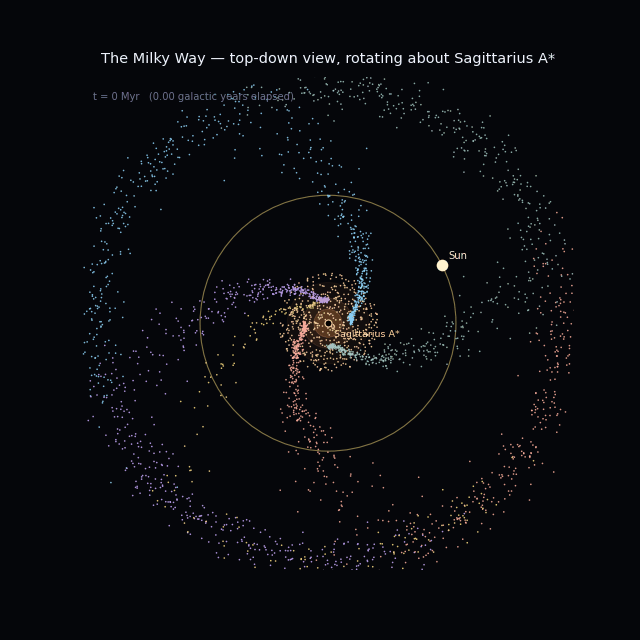

In [6]:

fig2, ax2 = plt.subplots(figsize=(8, 8))
ax2.set_facecolor('#05060a')
ax2.set_xlim(-GALAXY_R_KPC*1.05, GALAXY_R_KPC*1.05)
ax2.set_ylim(-GALAXY_R_KPC*1.05, GALAXY_R_KPC*1.05)
ax2.set_aspect('equal'); ax2.axis('off')
ax2.set_title("The Milky Way — top-down view, rotating about Sagittarius A*",
              color='#eef1fb', fontsize=13, pad=12)

# Sgr A* glow + marker
for radius, alpha in [(2.6, 0.05), (1.6, 0.10), (0.9, 0.22)]:
    ax2.add_patch(Circle((0, 0), radius, color='#ff9c4d', alpha=alpha, zorder=2))
ax2.scatter([0], [0], s=40, c='black', edgecolors='#ffcf9e', linewidths=1, zorder=5)
ax2.text(0.4, -0.9, "Sagittarius A*", color='#ffd7a8', fontsize=8.5, zorder=6)

# Sun's orbit path
sun_theta0 = np.pi * 0.15
orbit_circle = Circle((0, 0), R_SUN_KPC, fill=False, ec='#ffe27a', lw=1.0, alpha=0.5, zorder=1)
ax2.add_patch(orbit_circle)

star_scatter = ax2.scatter(all_r*np.cos(all_theta0), all_r*np.sin(all_theta0),
                            s=2.2, c=all_rgb, alpha=0.85, linewidths=0, zorder=3)
sun_dot = ax2.scatter([R_SUN_KPC*np.cos(sun_theta0)], [R_SUN_KPC*np.sin(sun_theta0)],
                       s=90, c='#fff3cf', zorder=6)
sun_label = ax2.text(0, 0, "Sun", color='#fff3cf', fontsize=9, zorder=6)
time_label = ax2.text(-GALAXY_R_KPC*1.0, GALAXY_R_KPC*0.95, "", color='#6b7391', fontsize=9)

MYR_PER_FRAME = 1.6

def update_galaxy(frame):
    t = frame * MYR_PER_FRAME
    theta = all_theta0 + all_omega * t
    star_scatter.set_offsets(np.column_stack([all_r*np.cos(theta), all_r*np.sin(theta)]))

    st = sun_theta0 + sun_omega * t
    sx, sy = R_SUN_KPC*np.cos(st), R_SUN_KPC*np.sin(st)
    sun_dot.set_offsets([[sx, sy]])
    sun_label.set_position((sx+0.4, sy+0.4))
    time_label.set_text(f"t = {t:,.0f} Myr   ({t/sun_period_myr:.2f} galactic years elapsed)")
    return [star_scatter, sun_dot, sun_label, time_label]

galaxy_anim = animation.FuncAnimation(fig2, update_galaxy, frames=70, interval=55, blit=False)
galaxy_anim.save("milky_way.gif", writer=animation.PillowWriter(fps=18))
plt.close(fig2)
Image(filename="milky_way.gif")



## 4. Summary

- Kepler's Third Law alone (§2.1) reproduces every planet's observed
  period to within a fraction of a percent — direct evidence that
  Newtonian gravity governs the Solar System to very high precision.
- The Sun's derived galactic year (§3.1), obtained purely from the
  measured flat rotation-curve speed and galactocentric radius, lands
  within the commonly cited **220–230 Myr** range — without ever
  plugging in Sgr A*'s mass, because the black hole itself contributes
  a negligible fraction of the mass enclosed within the solar orbit.
  What actually sets the Sun's orbital speed is the Galaxy's disk,
  bulge, and dark-matter halo.
- Sgr A*'s role is dynamical, not gravitational-in-bulk: it anchors the
  Galactic center that everything — including the spiral pattern —
  rotates around, while contributing only ~4.3 million of the
  ~10¹¹ solar masses inside the solar circle.

## References

- GRAVITY Collaboration, Abuter, R. et al. (2022). *"Mass distribution in the Galactic Center based on interferometric astrometry of multiple stellar orbits."* A&A, 657, L12.
- GRAVITY Collaboration (2019). *"A geometric distance measurement to the Galactic center black hole with 0.3% uncertainty."* A&A, 625, L10.
- Reid, M. J. & Honma, M. (2014). *"Microarcsecond Radio Astrometry."* Annual Review of Astronomy and Astrophysics, 52, 339–372.
- Vallée, J. P. (2017). *"A Different Pitch Angle for the Spiral Arms Traced by Different Astrophysical Tracers as Seen in the Milky Way Galaxy."* ApJ, 835, 128.
- Williams, D. R. *NASA Planetary Fact Sheets.* NASA Goddard Space Flight Center, nssdc.gsfc.nasa.gov/planetary/factsheet/.
